# Phase 3 — Feature engineering (FD001)

Objective: convert the raw per-cycle sensor readings into a feature matrix where each row
represents one engine's state at one cycle, expressed as statistics over its observable history.

See `doc/plan.md` Phase 3 for the full spec. This notebook covers the first activity, sensor
selection, plus three redundancy/collinearity checks on the selected sensors before any
rolling-window features are built from them: a pairwise correlation matrix, hierarchical
clustering on `1 - |r|`, and Variance Inflation Factor (VIF) for multivariate collinearity.

**Deviation from the plan default.** `doc/plan.md` Activity 1 specifies the "top 8 sensors by
`|correlation|` with RUL." Re-examining Phase 1's ranked correlation list (`pooled_corr_ranked`,
recomputed fresh below per this project's reload-per-notebook convention), the drop in `|r|` from
rank 12 to rank 13 is far larger than any other rank-to-rank gap in the list — a genuine elbow,
not an arbitrary cutoff. This notebook uses the **top 12** sensors instead of 8; see Section 1 for
the quantified gap. That changes the Phase 3 feature-count arithmetic from the plan's
138–141 estimate (8 sensors) to roughly 202–205 (12 sensors × 4 windows × 4 stats = 192 rolling +
9–12 lag + 1 cycle) once later activities in this phase are built.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage, set_link_color_palette
from scipy.spatial.distance import squareform
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

DATA_DIR = Path("../data")

# Fixed, colorblind-safe categorical palette (8 slots, ordered — do not reorder or cycle).
# Source: dataviz skill reference palette; validated on the adjacent-pairlist for line charts.
CATEGORICAL_PALETTE = [
    "#2a78d6",  # 1 blue
    "#eb6834",  # 2 orange
    "#1baf7a",  # 3 aqua
    "#eda100",  # 4 yellow
    "#e87ba4",  # 5 magenta
    "#008300",  # 6 green
    "#4a3aa7",  # 7 violet
    "#e34948",  # 8 red
]

# Diverging pair (blue <-> red, neutral gray midpoint) from the same reference palette — used
# below for the correlation heatmap, which encodes polarity (sign of r) + magnitude (|r|).
DIVERGING_NEG = "#e34948"  # red pole (categorical slot 8)
DIVERGING_MID = "#f0efec"  # neutral gray midpoint (light mode)
DIVERGING_POS = "#2a78d6"  # blue pole (categorical slot 1)
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "blue_gray_red", [DIVERGING_NEG, DIVERGING_MID, DIVERGING_POS]
)

SURFACE = "#fcfcfb"
GRIDLINE = "#e1e0d9"
AXIS = "#c3c2b7"
MUTED = "#898781"
INK = "#0b0b0b"

plt.rcParams["figure.facecolor"] = SURFACE
plt.rcParams["axes.facecolor"] = SURFACE
plt.rcParams["font.size"] = 10

## 0. Load data

Same parsing as Phase 0/1/2 — reload `train_df`, `test_df`, `rul_true` fresh in this notebook.

In [2]:
COLUMNS = (
    ["engine_id", "cycle", "op_1", "op_2", "op_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)


def load_fd001(filename: str) -> pd.DataFrame:
    df = pd.read_csv(
        DATA_DIR / filename,
        sep=r"\s+",
        header=None,
        names=COLUMNS,
    )
    df["engine_id"] = df["engine_id"].astype(int)
    df["cycle"] = df["cycle"].astype(int)
    return df


train_df = load_fd001("train_FD001.txt")
test_df = load_fd001("test_FD001.txt")

rul_true = pd.read_csv(
    DATA_DIR / "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["rul"],
)["rul"]
rul_true.index = rul_true.index + 1
rul_true.index.name = "engine_id"

SENSOR_COLS = [f"sensor_{i}" for i in range(1, 22)]

train_df.shape, test_df.shape, rul_true.shape

((20631, 26), (13096, 26), (100,))

## 1. Sensor selection — top 12 by pooled `|r|` with raw RUL

Same two-step method as Phase 1 Sections 2–3, recomputed fresh here:

1. **Near-constant exclusion.** Std `< 0.01` across all training rows excludes 7 sensors
   (`sensor_1, 5, 6, 10, 16, 18, 19`), leaving 14 informative sensors.
2. **Pooled Pearson correlation** of each informative sensor against raw RUL
   (`max_cycle - cycle`, uncapped — matching Phase 1's convention), ranked by `|r|`.

The plan's default is "top 8." Ranking the 14 informative sensors and looking at the *gap*
between consecutive ranks (not just the ranked list) is what decides whether 8, 12, or some other
cutoff is the right one — see the gap table below.

In [3]:
NEAR_CONSTANT_STD_THRESHOLD = 0.01

sensor_std = train_df[SENSOR_COLS].std()
NEAR_CONSTANT_SENSORS = sensor_std.index[sensor_std < NEAR_CONSTANT_STD_THRESHOLD].tolist()
INFORMATIVE_SENSORS = [s for s in SENSOR_COLS if s not in NEAR_CONSTANT_SENSORS]

train_df["rul_raw"] = (
    train_df.groupby("engine_id")["cycle"].transform("max") - train_df["cycle"]
)

pooled_corr = train_df[INFORMATIVE_SENSORS].corrwith(train_df["rul_raw"])
pooled_corr_ranked = pooled_corr.reindex(pooled_corr.abs().sort_values(ascending=False).index)

print("Near-constant (excluded):", NEAR_CONSTANT_SENSORS)
print()
pd.DataFrame({"pearson_r": pooled_corr_ranked, "abs_r": pooled_corr_ranked.abs()})

Near-constant (excluded): ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']



,pearson_r,abs_r
sensor_11,-0.696228,0.696228
sensor_4,-0.678948,0.678948
sensor_12,0.671983,0.671983
sensor_7,0.657223,0.657223
sensor_15,-0.642667,0.642667
sensor_21,0.635662,0.635662
sensor_20,0.629428,0.629428
sensor_2,-0.606484,0.606484
sensor_17,-0.606154,0.606154
sensor_3,-0.584520,0.584520


In [4]:
# Gap between consecutive ranks in |r| — this, not a fixed round number, is what should decide
# where to cut the sensor list.
abs_r = pooled_corr_ranked.abs()
gap_to_next = -abs_r.diff().shift(-1)  # gap[i] = |r|[i] - |r|[i+1]

gap_table = pd.DataFrame({"abs_r": abs_r, "gap_to_next_rank": gap_to_next})
gap_table.insert(0, "rank", range(1, len(gap_table) + 1))
gap_table

,rank,abs_r,gap_to_next_rank
sensor_11,1,0.696228,0.017280
sensor_4,2,0.678948,0.006965
sensor_12,3,0.671983,0.014760
sensor_7,4,0.657223,0.014556
sensor_15,5,0.642667,0.007005
sensor_21,6,0.635662,0.006234
sensor_20,7,0.629428,0.022945
sensor_2,8,0.606484,0.000330
sensor_17,9,0.606154,0.021633
sensor_3,10,0.584520,0.020552


In [5]:
TOP_N = 12
TOP_SENSORS = pooled_corr_ranked.index[:TOP_N].tolist()

sorted_gaps = gap_table.dropna(subset=["gap_to_next_rank"]).sort_values(
    "gap_to_next_rank", ascending=False
)

print("Top", TOP_N, "sensors:", TOP_SENSORS)
print()
print("Ranks sorted by gap size (largest first):")
sorted_gaps

Top 12 sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21', 'sensor_20', 'sensor_2', 'sensor_17', 'sensor_3', 'sensor_8', 'sensor_13']

Ranks sorted by gap size (largest first):


,rank,abs_r,gap_to_next_rank
sensor_13,12,0.562569,0.172467
sensor_9,13,0.390102,0.083333
sensor_20,7,0.629428,0.022945
sensor_17,9,0.606154,0.021633
sensor_3,10,0.584520,0.020552
sensor_11,1,0.696228,0.017280
sensor_12,3,0.671983,0.014760
sensor_7,4,0.657223,0.014556
sensor_15,5,0.642667,0.007005
sensor_4,2,0.678948,0.006965


**Result.** The gap from rank 12 (`sensor_13`, `|r|` = 0.563) to rank 13 (`sensor_9`, `|r|` =
0.390) is **0.172** — about **7.5x larger** than the next-biggest gap anywhere in the ranked list
(0.023, between rank 7 `sensor_20` and rank 8 `sensor_2`). Every other adjacent-rank gap among the
top 13 is under 0.023. This confirms the elbow is real, not an artifact of picking a
round number: `sensor_9` and `sensor_14` (ranks 13–14) are also exactly the two sensors Phase 1
flagged as having inconsistent per-engine correlation sign (Section 1b / 3b) — the size of this
gap and that independent finding agree, which is a second reason (beyond the `|r|` gap alone) that
rank 12 is where the "reliable degradation sensor" tier actually ends for FD001.

`TOP_SENSORS` (top 12, descending `|r|`): `sensor_11, sensor_4, sensor_12, sensor_7, sensor_15,
sensor_21, sensor_20, sensor_2, sensor_17, sensor_3, sensor_8, sensor_13`.

## 2. Pearson correlation matrix among the top 12 sensors — redundancy check

Before building rolling-window features from all 12 sensors (4 windows × 4 stats each = 48
features per sensor), check how much these sensors duplicate each other. If two sensors are
nearly the same signal, their rolling means/stds/mins/maxes will be nearly the same features too
— inflating the feature count without adding independent information. Compute the pairwise
Pearson correlation matrix among the 12 raw sensor columns themselves (not against RUL — sensor
vs. sensor).

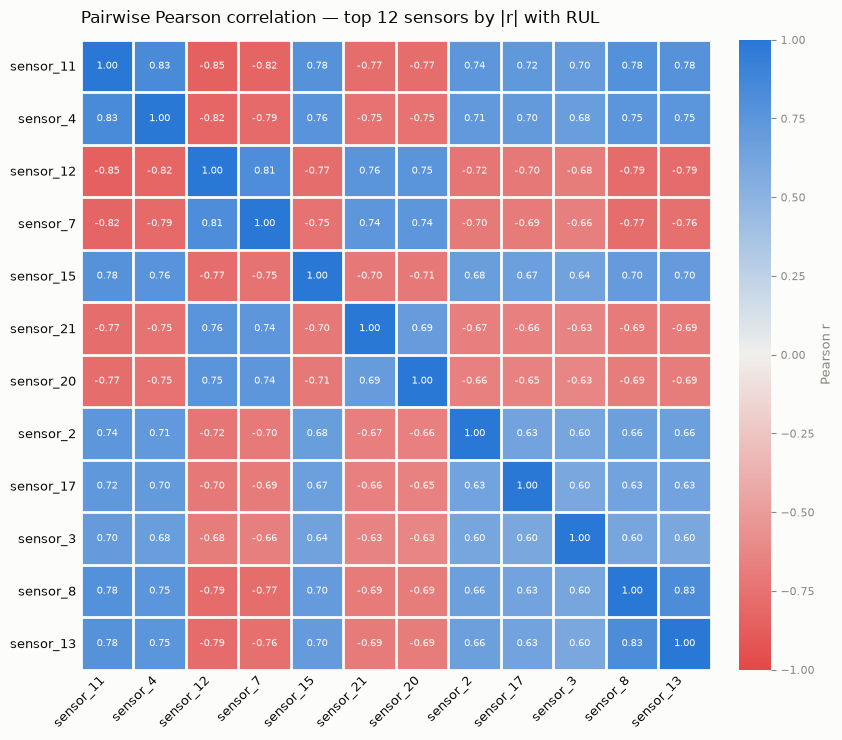

In [6]:
corr_matrix = train_df[TOP_SENSORS].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(corr_matrix.values, cmap=DIVERGING_CMAP, vmin=-1, vmax=1)

# thin surface-colored gaps between cells, consistent with the project's "2px surface gap
# between fills" mark convention
ax.set_xticks(np.arange(len(TOP_SENSORS) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(TOP_SENSORS) + 1) - 0.5, minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="minor", length=0)

ax.set_xticks(range(len(TOP_SENSORS)))
ax.set_yticks(range(len(TOP_SENSORS)))
ax.set_xticklabels(TOP_SENSORS, rotation=45, ha="right", fontsize=9, color=INK)
ax.set_yticklabels(TOP_SENSORS, fontsize=9, color=INK)
ax.tick_params(which="major", length=0)

for i in range(len(TOP_SENSORS)):
    for j in range(len(TOP_SENSORS)):
        r = corr_matrix.values[i, j]
        text_color = SURFACE if abs(r) > 0.5 else INK
        ax.text(j, i, f"{r:.2f}", ha="center", va="center", fontsize=7.5, color=text_color)

for side in ax.spines.values():
    side.set_visible(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson r", fontsize=9, color=MUTED)
cbar.ax.tick_params(labelsize=8, colors=MUTED)
cbar.outline.set_visible(False)

ax.set_title(
    "Pairwise Pearson correlation — top 12 sensors by |r| with RUL",
    fontsize=12, color=INK, loc="left", pad=12,
)

fig.tight_layout()
plt.show()

In [7]:
# Quantify what the heatmap shows: the strongest (most redundant) and weakest pairs among the 12.
from itertools import combinations

pairs = pd.Series(
    {(a, b): corr_matrix.loc[a, b] for a, b in combinations(TOP_SENSORS, 2)}
).abs().sort_values(ascending=False)
pairs.index = pd.MultiIndex.from_tuples(pairs.index, names=["sensor_a", "sensor_b"])

print(f"pairwise |r| range across all {len(pairs)} pairs: [{pairs.min():.3f}, {pairs.max():.3f}]")
print()
print("Top 6 most-correlated (most redundant) pairs:")
print(pairs.head(6))
print()
print("Bottom 6 least-correlated pairs:")
print(pairs.tail(6))

pairwise |r| range across all 66 pairs: [0.600, 0.847]

Top 6 most-correlated (most redundant) pairs:
sensor_a   sensor_b 
sensor_11  sensor_12    0.846884
           sensor_4     0.830136
sensor_8   sensor_13    0.826084
sensor_11  sensor_7     0.822805
sensor_4   sensor_12    0.815591
sensor_12  sensor_7     0.812713
dtype: float64

Bottom 6 least-correlated pairs:
sensor_a   sensor_b 
sensor_17  sensor_13    0.627410
sensor_20  sensor_3     0.625941
sensor_2   sensor_3     0.602610
sensor_3   sensor_8     0.602481
           sensor_13    0.600963
sensor_17  sensor_3     0.600017
dtype: float64


**Result.** Every one of the 66 pairs among the top 12 sensors has `|r| >= 0.60` — there is no
weakly-related pair at all. That's expected, not a bug: these are exactly the 12 sensors that
Phase 1 identified as tracking the same underlying degradation process, so they move together by
construction. The two standout pairs are `sensor_11`/`sensor_12` (`|r|` = 0.85) and
`sensor_8`/`sensor_13` (`|r|` = 0.83) — the latter matches Phase 1 Section 3's own flag that
`sensor_8` and `sensor_13` are a "near-duplicate pair" (near-identical mean and std, 100% sign
agreement across engines). High pairwise correlation everywhere means the redundancy in this
sensor set isn't concentrated in one or two sensors that could simply be dropped — it's structural
across all 12 — but the two standout pairs are the strongest candidates if Phase 3's later rolling-
feature count needs trimming.

## 3. Hierarchical clustering — dendrogram, distance = 1 − `|r|`

The correlation matrix in Section 2 shows pairwise redundancy but not *grouping*: which sensors
cluster together, and how tightly, before any rolling-window features are built from them.
Convert the correlation matrix to a distance matrix (`1 - |r|`: 0 = identical signal, larger =
less similar) and run average-linkage hierarchical clustering.

In [8]:
dist = (1 - corr_matrix.abs()).to_numpy(copy=True)
np.fill_diagonal(dist, 0.0)
dist = (dist + dist.T) / 2  # enforce exact symmetry against floating-point round-off

condensed_dist = squareform(dist, checks=False)
Z = linkage(condensed_dist, method="average")

pd.DataFrame(
    Z, columns=["cluster_a", "cluster_b", "distance", "n_members"]
)

,cluster_a,cluster_b,distance,n_members
0,0.0,2.0,0.153116,2.0
1,10.0,11.0,0.173916,2.0
2,1.0,12.0,0.177137,3.0
3,3.0,14.0,0.190451,4.0
4,13.0,15.0,0.229786,6.0
5,4.0,16.0,0.258152,7.0
6,5.0,17.0,0.272388,8.0
7,6.0,18.0,0.277245,9.0
8,7.0,19.0,0.309815,10.0
9,8.0,20.0,0.331381,11.0


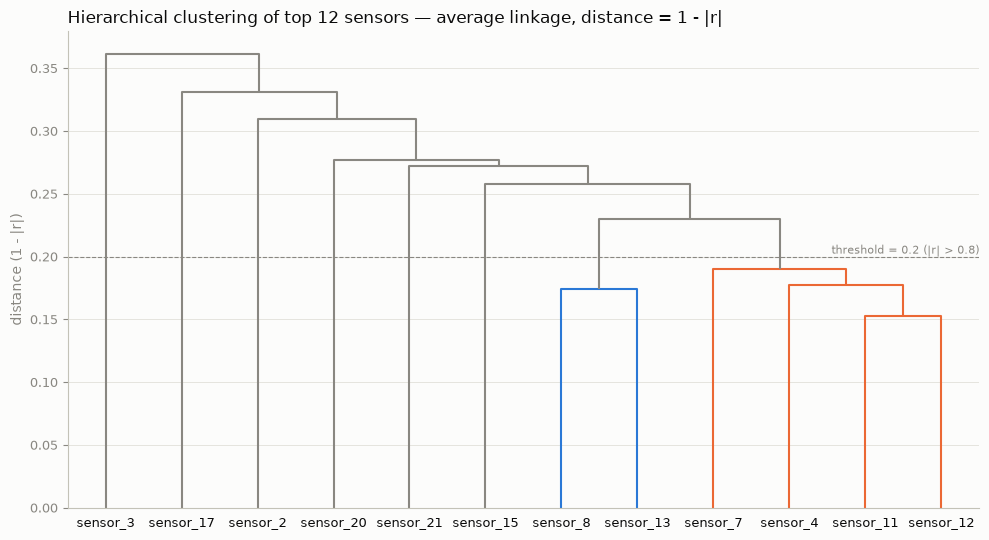

In [9]:
# color_threshold = 0.2 -> |r| > 0.8: highlights sub-clusters where sensors are tightly redundant.
# Below-threshold links get fixed categorical colors (identity of a cluster); above-threshold
# links (looser merges) stay muted gray rather than an arbitrary extra hue.
set_link_color_palette(CATEGORICAL_PALETTE[:2])

fig, ax = plt.subplots(figsize=(10, 5.5))

dendrogram(
    Z,
    labels=TOP_SENSORS,
    color_threshold=0.2,
    above_threshold_color=MUTED,
    ax=ax,
)

ax.axhline(0.2, color=MUTED, linewidth=0.8, linestyle="--")
ax.text(
    ax.get_xlim()[1], 0.2, "  threshold = 0.2 (|r| > 0.8)",
    fontsize=8, color=MUTED, va="bottom", ha="right",
)

ax.set_ylabel("distance (1 - |r|)", fontsize=10, color=MUTED)
ax.set_title(
    "Hierarchical clustering of top 12 sensors — average linkage, distance = 1 - |r|",
    fontsize=12, color=INK, loc="left",
)
ax.tick_params(axis="x", colors=INK, labelsize=9)
ax.tick_params(axis="y", colors=MUTED, labelsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.grid(True, axis="y", color=GRIDLINE, linewidth=0.6)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

In [10]:
from scipy.cluster.hierarchy import fcluster

clusters_at_threshold = pd.Series(
    fcluster(Z, t=0.2, criterion="distance"), index=TOP_SENSORS, name="cluster"
).sort_values()
clusters_at_threshold

sensor_8     1
sensor_13    1
sensor_11    2
sensor_4     2
sensor_12    2
sensor_7     2
sensor_15    3
sensor_21    4
sensor_20    5
sensor_2     6
sensor_17    7
sensor_3     8
Name: cluster, dtype: int32

**Result.** The two earliest (tightest) merges are exactly the two standout pairs from Section 2:
`sensor_11` + `sensor_12` at distance 0.153 (`|r|` = 0.85), then `sensor_8` + `sensor_13` at
distance 0.174 (`|r|` = 0.83) — the dendrogram and the raw correlation matrix agree on where the
sharpest redundancy sits, computed two different ways.

At the `distance = 0.2` (`|r| > 0.8`) threshold, the 12 sensors split into 8 groups: a 4-sensor
cluster (`sensor_11, sensor_4, sensor_12, sensor_7` — the 4 highest-ranked sensors by correlation
with RUL from Section 1), a 2-sensor cluster (`sensor_8, sensor_13`), and 6 sensors still singletons
at this threshold. Everything eventually fuses into one cluster by distance ~0.36 (`|r|` ~ 0.64),
matching Section 2's finding that no pair among the 12 drops below `|r|` = 0.60 — there's no
natural "unrelated" boundary anywhere in this set, only a gradient from very redundant to somewhat
redundant.

Sections 2–3 both measure *pairwise* redundancy — how much sensor A duplicates sensor B alone.
That's not the same question as *multivariate* collinearity — how much sensor A is a linear
combination of all 11 other sensors combined, which is what actually destabilizes a linear model's
coefficients. Section 4 checks that directly with VIF.

## 4. Variance Inflation Factor (VIF) — multivariate collinearity check

VIF quantifies, for each sensor, how well it can be predicted by a linear combination of the
*other 11* — `VIF = 1 / (1 - R^2)` from regressing that sensor on the rest. Unlike Sections 2–3,
this can catch collinearity that no single pair reveals: a sensor could have only moderate
correlation with any one other sensor individually, yet still be almost fully reconstructable from
several of them combined. Common rule of thumb: `VIF > 5` = moderate concern, `VIF > 10` =
severe (the predictor is redundant enough to make regression coefficients unstable).

In [11]:
X = add_constant(train_df[TOP_SENSORS])

vif = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])],
    index=TOP_SENSORS,
    name="VIF",
).sort_values(ascending=False)

pd.DataFrame({
    "VIF": vif,
    "flag": np.where(vif > 10, "severe (>10)", np.where(vif > 5, "moderate (>5)", "ok")),
})

,VIF,flag
sensor_11,5.910382,moderate (>5)
sensor_12,5.255676,moderate (>5)
sensor_4,4.469245,ok
sensor_7,4.326144,ok
sensor_8,4.015807,ok
sensor_13,3.999419,ok
sensor_15,3.236505,ok
sensor_21,3.050410,ok
sensor_20,3.018425,ok
sensor_2,2.605926,ok


**Result.** VIF ranges from 2.22 (`sensor_3`) to 5.91 (`sensor_11`). Only 2 of the 12 sensors
cross the moderate-concern line (`VIF > 5`): `sensor_11` (5.91) and `sensor_12` (5.26) — the same
pair the dendrogram merged first. None crosses the severe threshold (`VIF > 10`).

This is a real, useful disagreement with Sections 2–3, not a contradiction: every pairwise `|r|`
among the 12 sensors is `>= 0.60` (Section 2), which looks alarming in isolation, but no sensor
turns out to be a near-perfect linear combination of the other 11 — each still carries some
variance the rest can't jointly reconstruct. Practically: the pairwise view (Sections 2–3) is the
more informative one for *this* project, because it directly predicts which sensors' Phase 3
rolling-window features will end up near-duplicates of each other (a pairwise, not multivariate,
concern) — `sensor_8`/`sensor_13` and `sensor_11`/`sensor_12` again stand out as the closest
pairs. VIF is the more relevant check for the Phase 4 linear-degradation baseline, where
multicollinearity among predictors destabilizes fitted coefficients directly — and by that
standard, all 12 sensors are safe to use together as-is; none needs to be dropped for coefficient
stability.